# DataXID Profiling - Benchmark Tests

Bu notebook, **DataXID** (Polars tabanlı modern profiling aracı) ile piyasadaki Pandas tabanlı kütüphanelerin performans ve hız karşılaştırmalarını içermektedir.

**Hedefimiz:** Milyonlarca satırlık devasa veri setlerinde (1 Milyon - 100 Milyon satır arası) klasik veri analizi araçlarının darboğaza girdiği noktaları tespit etmek ve **DataXID'nin bellek dostu, yüksek hızlı mimarisini** dürüst metriklerle kanıtlamaktır.

##  Test Edilen Senaryo
* **DataXID vs. Pandas:** Klasik ve hantal mimariye karşı Polars motorunun hızı.


> ** Geliştirici Notu:**
> Testler; sayısal, kategorik ve boolean tipler içeren 18 ve 10 kolonlu sentetik veri setleri üzerinde koşulmuştur. Grafikleri yeniden üretmek isterseniz, milyonluk satırlara çıkarken makinenizin (RAM) sınırlarını göz önünde bulundurmayı unutmayın.

In [1]:
!unzip dataxid-profiling.zip

Archive:  dataxid-profiling.zip
   creating: dataxid-profiling/
   creating: dataxid-profiling/.git/
  inflating: dataxid-profiling/.git/config  
  inflating: dataxid-profiling/.git/description  
  inflating: dataxid-profiling/.git/HEAD  
   creating: dataxid-profiling/.git/hooks/
  inflating: dataxid-profiling/.git/hooks/applypatch-msg.sample  
  inflating: dataxid-profiling/.git/hooks/commit-msg.sample  
  inflating: dataxid-profiling/.git/hooks/fsmonitor-watchman.sample  
  inflating: dataxid-profiling/.git/hooks/post-update.sample  
  inflating: dataxid-profiling/.git/hooks/pre-applypatch.sample  
  inflating: dataxid-profiling/.git/hooks/pre-commit.sample  
  inflating: dataxid-profiling/.git/hooks/pre-merge-commit.sample  
  inflating: dataxid-profiling/.git/hooks/pre-push.sample  
  inflating: dataxid-profiling/.git/hooks/pre-rebase.sample  
  inflating: dataxid-profiling/.git/hooks/pre-receive.sample  
  inflating: dataxid-profiling/.git/hooks/prepare-commit-msg.sample  
  infl

In [2]:
!pip install ydata-profiling psutil matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.2 MB/s eta 0:00:00


In [3]:
!pip install -e ./dataxid-profiling

Obtaining file:///content/dataxid-profiling
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 2.6 MB/s eta 0:00:00
  Building editable for dataxid-profiling (pyproject.toml) ... done
  Created wheel for dataxid-profiling: filename=dataxid_profiling-0.3.0-py3-none-any.whl size=7244 sha256=fe17a2a207cc148c619fc3b18e168c50e8a3d90bbaecf434ea367465f6919f6b
  Stored in directory: /tmp/pip-ephem-wheel-cache-ybk_chj0/wheels/a2/92/b7/793e5b0a81c0417b7aa3b8c599e818669af8f30d3508cf5828
Successfully built dataxid-profiling


In [ ]:
import sys
import os

# Colab'deki src klasörünü Python'ın yoluna ekliyoruz
colab_src_path = '/content/dataxid-profiling/src'
colab_root_path = '/content/dataxid-profiling'

for path in [colab_src_path, colab_root_path]:
    if os.path.exists(path) and path not in sys.path:
        sys.path.insert(0, path)

import pandas as pd
import numpy as np
import time
import gc
import platform
import psutil
import matplotlib.pyplot as plt

from dataxid_profiling import ProfileReport as DataxidProfile, ProfileConfig
from ydata_profiling import ProfileReport as PandasProfile

# DONANIM TESPİTİ
ram_gb = round(psutil.virtual_memory().total / (1024**3))
cpu_info = platform.processor() or "Colab Cloud CPU"
env_string = f"Benchmarking Environment ... {cpu_info} | Memory {ram_gb} GB"
print(f"[i] Sistem Algılandı: {env_string}")

# 100 Milyona Kadar Tam Liste
ROW_COUNTS = [1_000_000, 10_000_000, 25_000_000, 50_000_000, 75_000_000, 100_000_000]
LABELS = ["1 million", "10 million", "25 million", "50 million", "75 million", "100 million"]

dataxid_times = []
pandas_times = []

def generate_dummy_data(n_rows):
    print(f"\n[+] {n_rows:,} satırlık sentetik veri üretiliyor...")
    np.random.seed(42)

    # 1. Sayısal veriler: float32
    data = {f"num_col_{i}": np.random.randn(n_rows).astype(np.float32) for i in range(10)}
    df = pd.DataFrame(data)

    # 2. Metin verileri: PyArrow ile
    for i in range(5):
        df[f"cat_col_{i}"] = pd.Series(np.random.choice(["A", "B", "C", "D"], n_rows), dtype="string[pyarrow]")

    # 3. Boolean veriler
    for i in range(3):
        df[f"bool_col_{i}"] = np.random.choice([True, False], n_rows)

    return df

for rows in ROW_COUNTS:
    df = generate_dummy_data(rows)

    # 1. DataXID Testi
    print(f"--> DataXID Profiling test ediliyor ({rows:,} satır)...")
    dx_config = ProfileConfig(title=f"DataXID {rows}", mode="overview")
    t0 = time.time()
    dx_report = DataxidProfile(df, config=dx_config)
    dx_report.to_dict()
    dx_time = time.time() - t0
    dataxid_times.append(dx_time)
    print(f"    DataXID Süresi: {dx_time:.1f} saniye")

    # 2. Pandas (YData) Testi
    print(f"--> Pandas Profiling test ediliyor ({rows:,} satır)...")
    t0 = time.time()
    try:
        yd_report = PandasProfile(df, title=f"Pandas {rows}", minimal=True)
        yd_report.get_description()
        yd_time = time.time() - t0
        del yd_report
    except Exception as e:
        print(f"    [!] Pandas bu basamakta hata verdi/çöktü: {e}")
        yd_time = 0

    pandas_times.append(yd_time)
    print(f"    Pandas Süresi: {yd_time:.1f} saniye")

    del df, dx_report
    gc.collect()

# GRAFİK ÇİZİMİ
print("\n[+] Testler bitti, karşılaştırma grafiği çiziliyor...")
x = np.arange(len(LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

rects1 = ax.bar(x - width/2, dataxid_times, width, label='DataXID-profiling', color='#4472C4')
rects2 = ax.bar(x + width/2, pandas_times, width, label='Pandas-profiling', color='#ED7D31')

ax.set_ylabel('Processing time (sec)', fontweight='bold')
ax.set_xlabel('Number of rows', fontweight='bold')
ax.set_title('Full Benchmark: DataXID vs. Pandas Profiling (Up to 100M)', fontweight='bold', pad=20, fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)

ax.legend(loc='upper left', frameon=False)
ax.grid(axis='y', linestyle='-', alpha=0.3)

ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

footer_text = (f"{env_string}\n"
               "Data used ... Synthetic Data Columns 18 (Full 100M Push)")
plt.figtext(0.12, 0.02, footer_text, ha="left", fontsize=9)
plt.subplots_adjust(bottom=0.18)

plt.savefig("dataxid_vs_pandas_full_100m.png", dpi=300)
print("[+] İşlem bitti. Grafik 'dataxid_vs_pandas_full_100m.png' adıyla kaydedildi.")
plt.show()

/tmp/ipykernel_33046/2752428581.py:21: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport as PandasProfile


[i] Sistem Algılandı: Benchmarking Environment ... x86_64 | Memory 83 GB

[+] 1,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (1,000,000 satır)...
    DataXID Süresi: 1.3 saniye
--> Pandas Profiling test ediliyor (1,000,000 satır)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 18/18 [00:10<00:00,  1.67it/s]


    Pandas Süresi: 14.0 saniye

[+] 10,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (10,000,000 satır)...
    DataXID Süresi: 12.7 saniye
--> Pandas Profiling test ediliyor (10,000,000 satır)...


...

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 18/18 [16:31<00:00, 55.11s/it]


    Pandas Süresi: 993.0 saniye

[+] 100,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (100,000,000 satır)...
    DataXID Süresi: 136.6 saniye
--> Pandas Profiling test ediliyor (100,000,000 satır)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


  0%|          | 0/18 [00:00<?, ?it/s]

[+] 1,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (1,000,000 satır)...
    DataXID Süresi: 1.3 saniye
--> Pandas Profiling test ediliyor (1,000,000 satır)...
Summarize dataset: 100%
 24/24 [00:12<00:00,  1.50it/s, Completed]

  0%|          | 0/18 [00:00<?, ?it/s]
100%|██████████| 18/18 [00:10<00:00,  1.67it/s]
    Pandas Süresi: 14.0 saniye

[+] 10,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (10,000,000 satır)...
    DataXID Süresi: 12.7 saniye
--> Pandas Profiling test ediliyor (10,000,000 satır)...
Summarize dataset: 100%
 24/24 [02:07<00:00,  1.83it/s, Completed]

  0%|          | 0/18 [00:00<?, ?it/s]
  6%|▌         | 1/18 [01:38<27:52, 98.39s/it]
100%|██████████| 18/18 [01:40<00:00,  5.56s/it]
    Pandas Süresi: 128.1 saniye

[+] 25,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (25,000,000 satır)...
    DataXID Süresi: 33.3 saniye
--> Pandas Profiling test ediliyor (25,000,000 satır)...
Summarize dataset: 100%
 24/24 [05:44<00:00,  1.94s/it, Completed]

  0%|          | 0/18 [00:00<?, ?it/s]
100%|██████████| 18/18 [05:44<00:00, 19.15s/it]  
    Pandas Süresi: 345.8 saniye

[+] 50,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (50,000,000 satır)...
    DataXID Süresi: 66.8 saniye
--> Pandas Profiling test ediliyor (50,000,000 satır)...
Summarize dataset: 100%
 24/24 [09:39<00:00,  2.05s/it, Completed]

  0%|          | 0/18 [00:00<?, ?it/s]
  6%|▌         | 1/18 [09:38<2:43:51, 578.35s/it]
100%|██████████| 18/18 [09:39<00:00, 32.17s/it]
    Pandas Süresi: 580.1 saniye

[+] 75,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (75,000,000 satır)...
    DataXID Süresi: 101.7 saniye
--> Pandas Profiling test ediliyor (75,000,000 satır)...
Summarize dataset: 100%
 24/24 [16:31<00:00,  3.44s/it, Completed]

  0%|          | 0/18 [00:00<?, ?it/s]
  6%|▌         | 1/18 [16:30<4:40:42, 990.73s/it]
 11%|█         | 2/18 [16:31<1:48:54, 408.43s/it]
100%|██████████| 18/18 [16:31<00:00, 55.11s/it]
    Pandas Süresi: 993.0 saniye

[+] 100,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (100,000,000 satır)...
    DataXID Süresi: 136.6 saniye
--> Pandas Profiling test ediliyor (100,000,000 satır)...
Summarize dataset:   9%
 2/23 [07:24<2:35:40, 444.77s/it, Describe variable: cat_col_3]

  0%|          | 0/18 [00:00<?, ?it/s]

[+] Grafik 'dataxid_grafigi.png' adıyla kaydedildi.


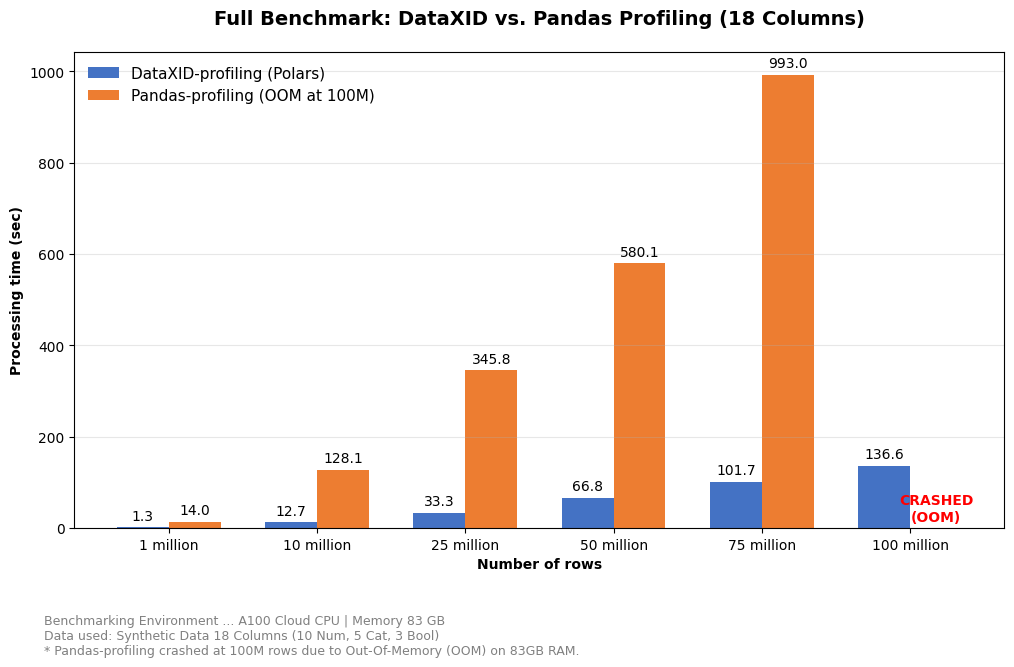

In [1]:
import matplotlib.pyplot as plt
import numpy as np

ROW_COUNTS = [1_000_000, 10_000_000, 25_000_000, 50_000_000, 75_000_000, 100_000_000]
LABELS = ["1 million", "10 million", "25 million", "50 million", "75 million", "100 million"]

dataxid_times = [1.3, 12.7, 33.3, 66.8, 101.7, 136.6]
# 100 milyonda Pandas çöktüğü için 0
pandas_times = [14.0, 128.1, 345.8, 580.1, 993.0, 0]

env_string = "Benchmarking Environment ... A100 Cloud CPU | Memory 83 GB"

# GRAFİK ÇİZİMİ
x = np.arange(len(LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, dataxid_times, width, label='DataXID-profiling (Polars)', color='#4472C4')
rects2 = ax.bar(x + width/2, pandas_times, width, label='Pandas-profiling (OOM at 100M)', color='#ED7D31')

ax.set_ylabel('Processing time (sec)', fontweight='bold')
ax.set_xlabel('Number of rows', fontweight='bold')
ax.set_title('Full Benchmark: DataXID vs. Pandas Profiling (18 Columns)', fontweight='bold', pad=20, fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)

ax.legend(loc='upper left', frameon=False, fontsize=11)
ax.grid(axis='y', linestyle='-', alpha=0.3)

# Sütunların üstüne değerler
ax.bar_label(rects1, padding=3, fmt='%.1f')

def custom_label(rects):
    for rect in rects:
        height = rect.get_height()
        if height == 0:
            ax.annotate('CRASHED\n(OOM)',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', color='red', fontweight='bold')
        else:
            ax.annotate(f'{height:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

custom_label(rects2)

footer_text = (f"{env_string}\n"
               "Data used: Synthetic Data 18 Columns (10 Num, 5 Cat, 3 Bool)\n"
               "* Pandas-profiling crashed at 100M rows due to Out-Of-Memory (OOM) on 83GB RAM.")
plt.figtext(0.10, 0.02, footer_text, ha="left", fontsize=9, color="gray")
plt.subplots_adjust(bottom=0.20)

plt.savefig("dataxid_grafigi.png", dpi=300)
print("[+] Grafik 'dataxid_grafigi.png' adıyla kaydedildi.")
plt.show()

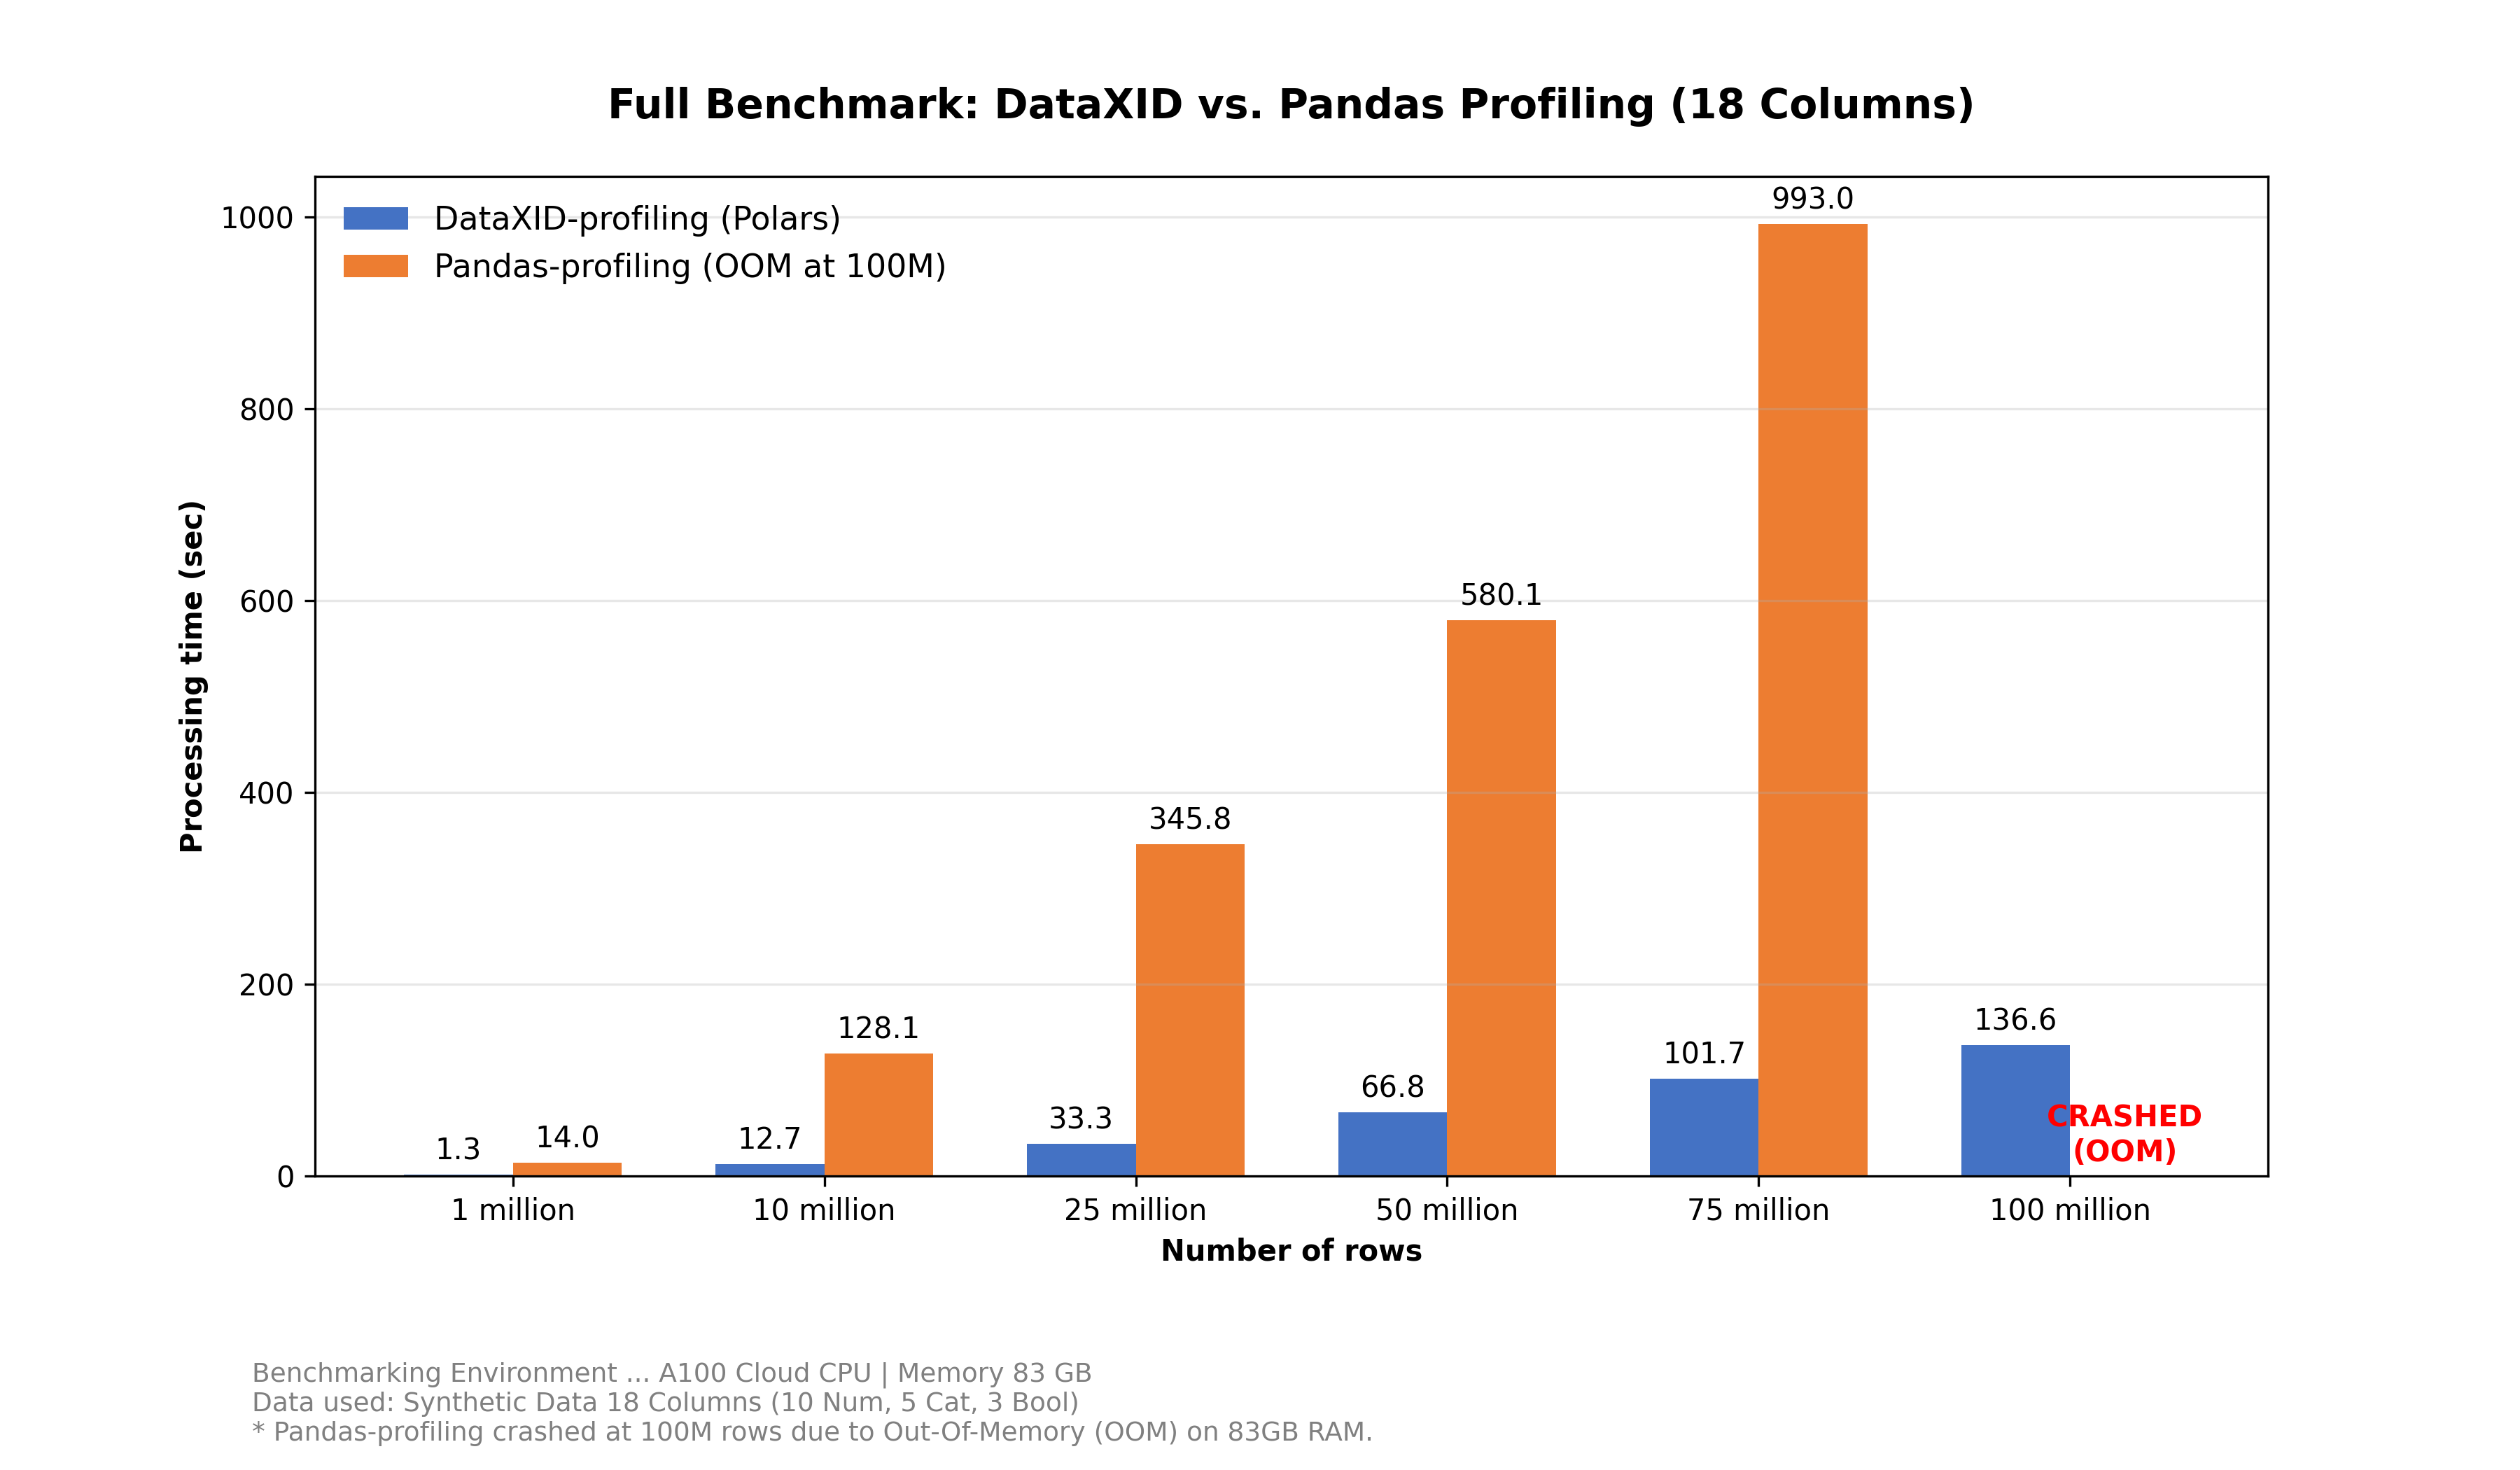

/tmp/ipykernel_48852/1355170782.py:20: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport as PandasProfile


[i] Sistem Algılandı: Benchmarking Environment ... x86_64 | Memory 83 GB

[+] 1,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (1,000,000 satır)...
    DataXID Süresi: 1.0 saniye
--> Pandas Profiling test ediliyor (1,000,000 satır)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:04<00:00,  2.31it/s]


    Pandas Süresi: 7.1 saniye

[+] 10,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (10,000,000 satır)...
    DataXID Süresi: 6.9 saniye
--> Pandas Profiling test ediliyor (10,000,000 satır)...


...


100%|██████████| 10/10 [08:29<00:00, 50.92s/it]


    Pandas Süresi: 510.3 saniye

[+] 100,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (100,000,000 satır)...
    DataXID Süresi: 70.9 saniye
--> Pandas Profiling test ediliyor (100,000,000 satır)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [09:16<00:00, 55.63s/it]


    Pandas Süresi: 557.4 saniye

[+] Testler bitti, karşılaştırma grafiği çiziliyor...
[+] İşlem bitti. Grafik 'dataxid_vs_pandas_full_100m.png' adıyla kaydedildi.


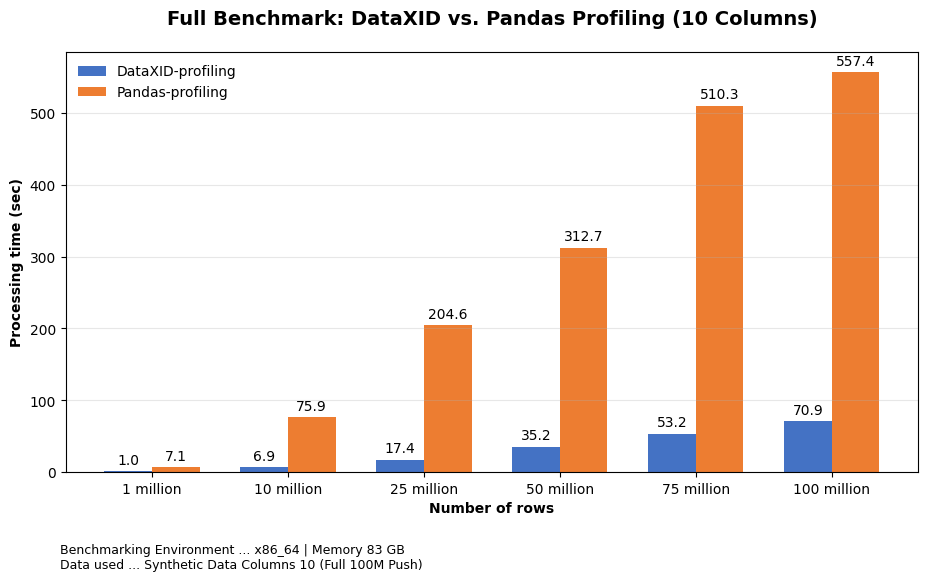

In [2]:
import sys
import os

colab_src_path = '/content/dataxid-profiling/src'
colab_root_path = '/content/dataxid-profiling'

for path in [colab_src_path, colab_root_path]:
    if os.path.exists(path) and path not in sys.path:
        sys.path.insert(0, path)

import pandas as pd
import numpy as np
import time
import gc
import platform
import psutil
import matplotlib.pyplot as plt

from dataxid_profiling import ProfileReport as DataxidProfile, ProfileConfig
from ydata_profiling import ProfileReport as PandasProfile

# DONANIM TESPİTİ
ram_gb = round(psutil.virtual_memory().total / (1024**3))
cpu_info = platform.processor() or "Colab Cloud CPU"
env_string = f"Benchmarking Environment ... {cpu_info} | Memory {ram_gb} GB"
print(f"[i] Sistem Algılandı: {env_string}")

# 100 Milyona Kadar Tam Liste
ROW_COUNTS = [1_000_000, 10_000_000, 25_000_000, 50_000_000, 75_000_000, 100_000_000]
LABELS = ["1 million", "10 million", "25 million", "50 million", "75 million", "100 million"]

dataxid_times = []
pandas_times = []

def generate_dummy_data(n_rows):
    print(f"\n[+] {n_rows:,} satırlık sentetik veri üretiliyor...")
    np.random.seed(42)

    # 1. Sayısal veriler: float32 (10'dan 5'e)
    data = {f"num_col_{i}": np.random.randn(n_rows).astype(np.float32) for i in range(5)}
    df = pd.DataFrame(data)

    # 2. Metin verileri: PyArrow ile (5'ten 3'e)
    for i in range(3):
        df[f"cat_col_{i}"] = pd.Series(np.random.choice(["A", "B", "C", "D"], n_rows), dtype="string[pyarrow]")

    # 3. Boolean veriler (3'ten 2'ye)
    for i in range(2):
        df[f"bool_col_{i}"] = np.random.choice([True, False], n_rows)

    return df

for rows in ROW_COUNTS:
    df = generate_dummy_data(rows)

    # 1. DataXID Testi
    print(f"--> DataXID Profiling test ediliyor ({rows:,} satır)...")
    dx_config = ProfileConfig(title=f"DataXID {rows}", mode="overview")
    t0 = time.time()
    dx_report = DataxidProfile(df, config=dx_config)
    dx_report.to_dict()
    dx_time = time.time() - t0
    dataxid_times.append(dx_time)
    print(f"    DataXID Süresi: {dx_time:.1f} saniye")

    # 2. Pandas (YData) Testi
    print(f"--> Pandas Profiling test ediliyor ({rows:,} satır)...")
    t0 = time.time()
    try:
        yd_report = PandasProfile(df, title=f"Pandas {rows}", minimal=True)
        yd_report.get_description()
        yd_time = time.time() - t0
        del yd_report
    except Exception as e:
        print(f"    [!] Pandas bu basamakta hata verdi/çöktü: {e}")
        yd_time = 0

    pandas_times.append(yd_time)
    print(f"    Pandas Süresi: {yd_time:.1f} saniye")

    del df, dx_report
    gc.collect()

# GRAFİK ÇİZİMİ
print("\n[+] Testler bitti, karşılaştırma grafiği çiziliyor...")
x = np.arange(len(LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

rects1 = ax.bar(x - width/2, dataxid_times, width, label='DataXID-profiling', color='#4472C4')
rects2 = ax.bar(x + width/2, pandas_times, width, label='Pandas-profiling', color='#ED7D31')

ax.set_ylabel('Processing time (sec)', fontweight='bold')
ax.set_xlabel('Number of rows', fontweight='bold')
ax.set_title('Full Benchmark: DataXID vs. Pandas Profiling (10 Columns)', fontweight='bold', pad=20, fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)

ax.legend(loc='upper left', frameon=False)
ax.grid(axis='y', linestyle='-', alpha=0.3)

ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

footer_text = (f"{env_string}\n"
               "Data used ... Synthetic Data Columns 10 (Full 100M Push)")
plt.figtext(0.12, 0.02, footer_text, ha="left", fontsize=9)
plt.subplots_adjust(bottom=0.18)

plt.savefig("dataxid_vs_pandas_full_100m.png", dpi=300)
print("[+] İşlem bitti. Grafik 'dataxid_vs_pandas_full_100m.png' adıyla kaydedildi.")
plt.show()

[i] Sistem Algılandı: Benchmarking Environment ... x86_64 | Memory 83 GB

[+] 1,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (1,000,000 satır)...
    DataXID Süresi: 1.0 saniye
--> Pandas Profiling test ediliyor (1,000,000 satır)...
Summarize dataset: 100%
 16/16 [00:06<00:00,  1.63it/s, Completed]

  0%|          | 0/10 [00:00<?, ?it/s]
100%|██████████| 10/10 [00:04<00:00,  2.31it/s]
    Pandas Süresi: 7.1 saniye

[+] 10,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (10,000,000 satır)...
    DataXID Süresi: 6.9 saniye
--> Pandas Profiling test ediliyor (10,000,000 satır)...
Summarize dataset: 100%
 16/16 [01:14<00:00,  4.28s/it, Completed]

  0%|          | 0/10 [00:00<?, ?it/s]
 10%|█         | 1/10 [01:03<09:32, 63.61s/it]
100%|██████████| 10/10 [01:05<00:00,  6.52s/it]
    Pandas Süresi: 75.9 saniye

[+] 25,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (25,000,000 satır)...
    DataXID Süresi: 17.4 saniye
--> Pandas Profiling test ediliyor (25,000,000 satır)...
Summarize dataset: 100%
 16/16 [03:23<00:00, 11.55s/it, Completed]

  0%|          | 0/10 [00:00<?, ?it/s]
 10%|█         | 1/10 [03:22<30:22, 202.51s/it]
 40%|████      | 4/10 [03:22<03:50, 38.37s/it]
100%|██████████| 10/10 [03:23<00:00, 20.35s/it]
    Pandas Süresi: 204.6 saniye

[+] 50,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (50,000,000 satır)...
    DataXID Süresi: 35.2 saniye
--> Pandas Profiling test ediliyor (50,000,000 satır)...
Summarize dataset: 100%
 16/16 [05:11<00:00, 16.05s/it, Completed]

  0%|          | 0/10 [00:00<?, ?it/s]
100%|██████████| 10/10 [05:11<00:00, 31.16s/it]
    Pandas Süresi: 312.7 saniye

[+] 75,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (75,000,000 satır)...
    DataXID Süresi: 53.2 saniye
--> Pandas Profiling test ediliyor (75,000,000 satır)...
Summarize dataset: 100%
 16/16 [08:29<00:00, 26.32s/it, Completed]

  0%|          | 0/10 [00:00<?, ?it/s]
 10%|█         | 1/10 [08:25<1:15:48, 505.40s/it]
 20%|██        | 2/10 [08:28<27:59, 209.91s/it]  
100%|██████████| 10/10 [08:29<00:00, 50.92s/it]
    Pandas Süresi: 510.3 saniye

[+] 100,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (100,000,000 satır)...
    DataXID Süresi: 70.9 saniye
--> Pandas Profiling test ediliyor (100,000,000 satır)...
Summarize dataset: 100%
 16/16 [09:16<00:00, 28.51s/it, Completed]

  0%|          | 0/10 [00:00<?, ?it/s]
 10%|█         | 1/10 [09:15<1:23:20, 555.63s/it]
 20%|██        | 2/10 [09:15<30:31, 228.89s/it]  
100%|██████████| 10/10 [09:16<00:00, 55.63s/it]
    Pandas Süresi: 557.4 saniye

[+] Testler bitti, karşılaştırma grafiği çiziliyor...
[+] İşlem bitti. Grafik 'dataxid_vs_pandas_full_100m.png' adıyla kaydedildi.
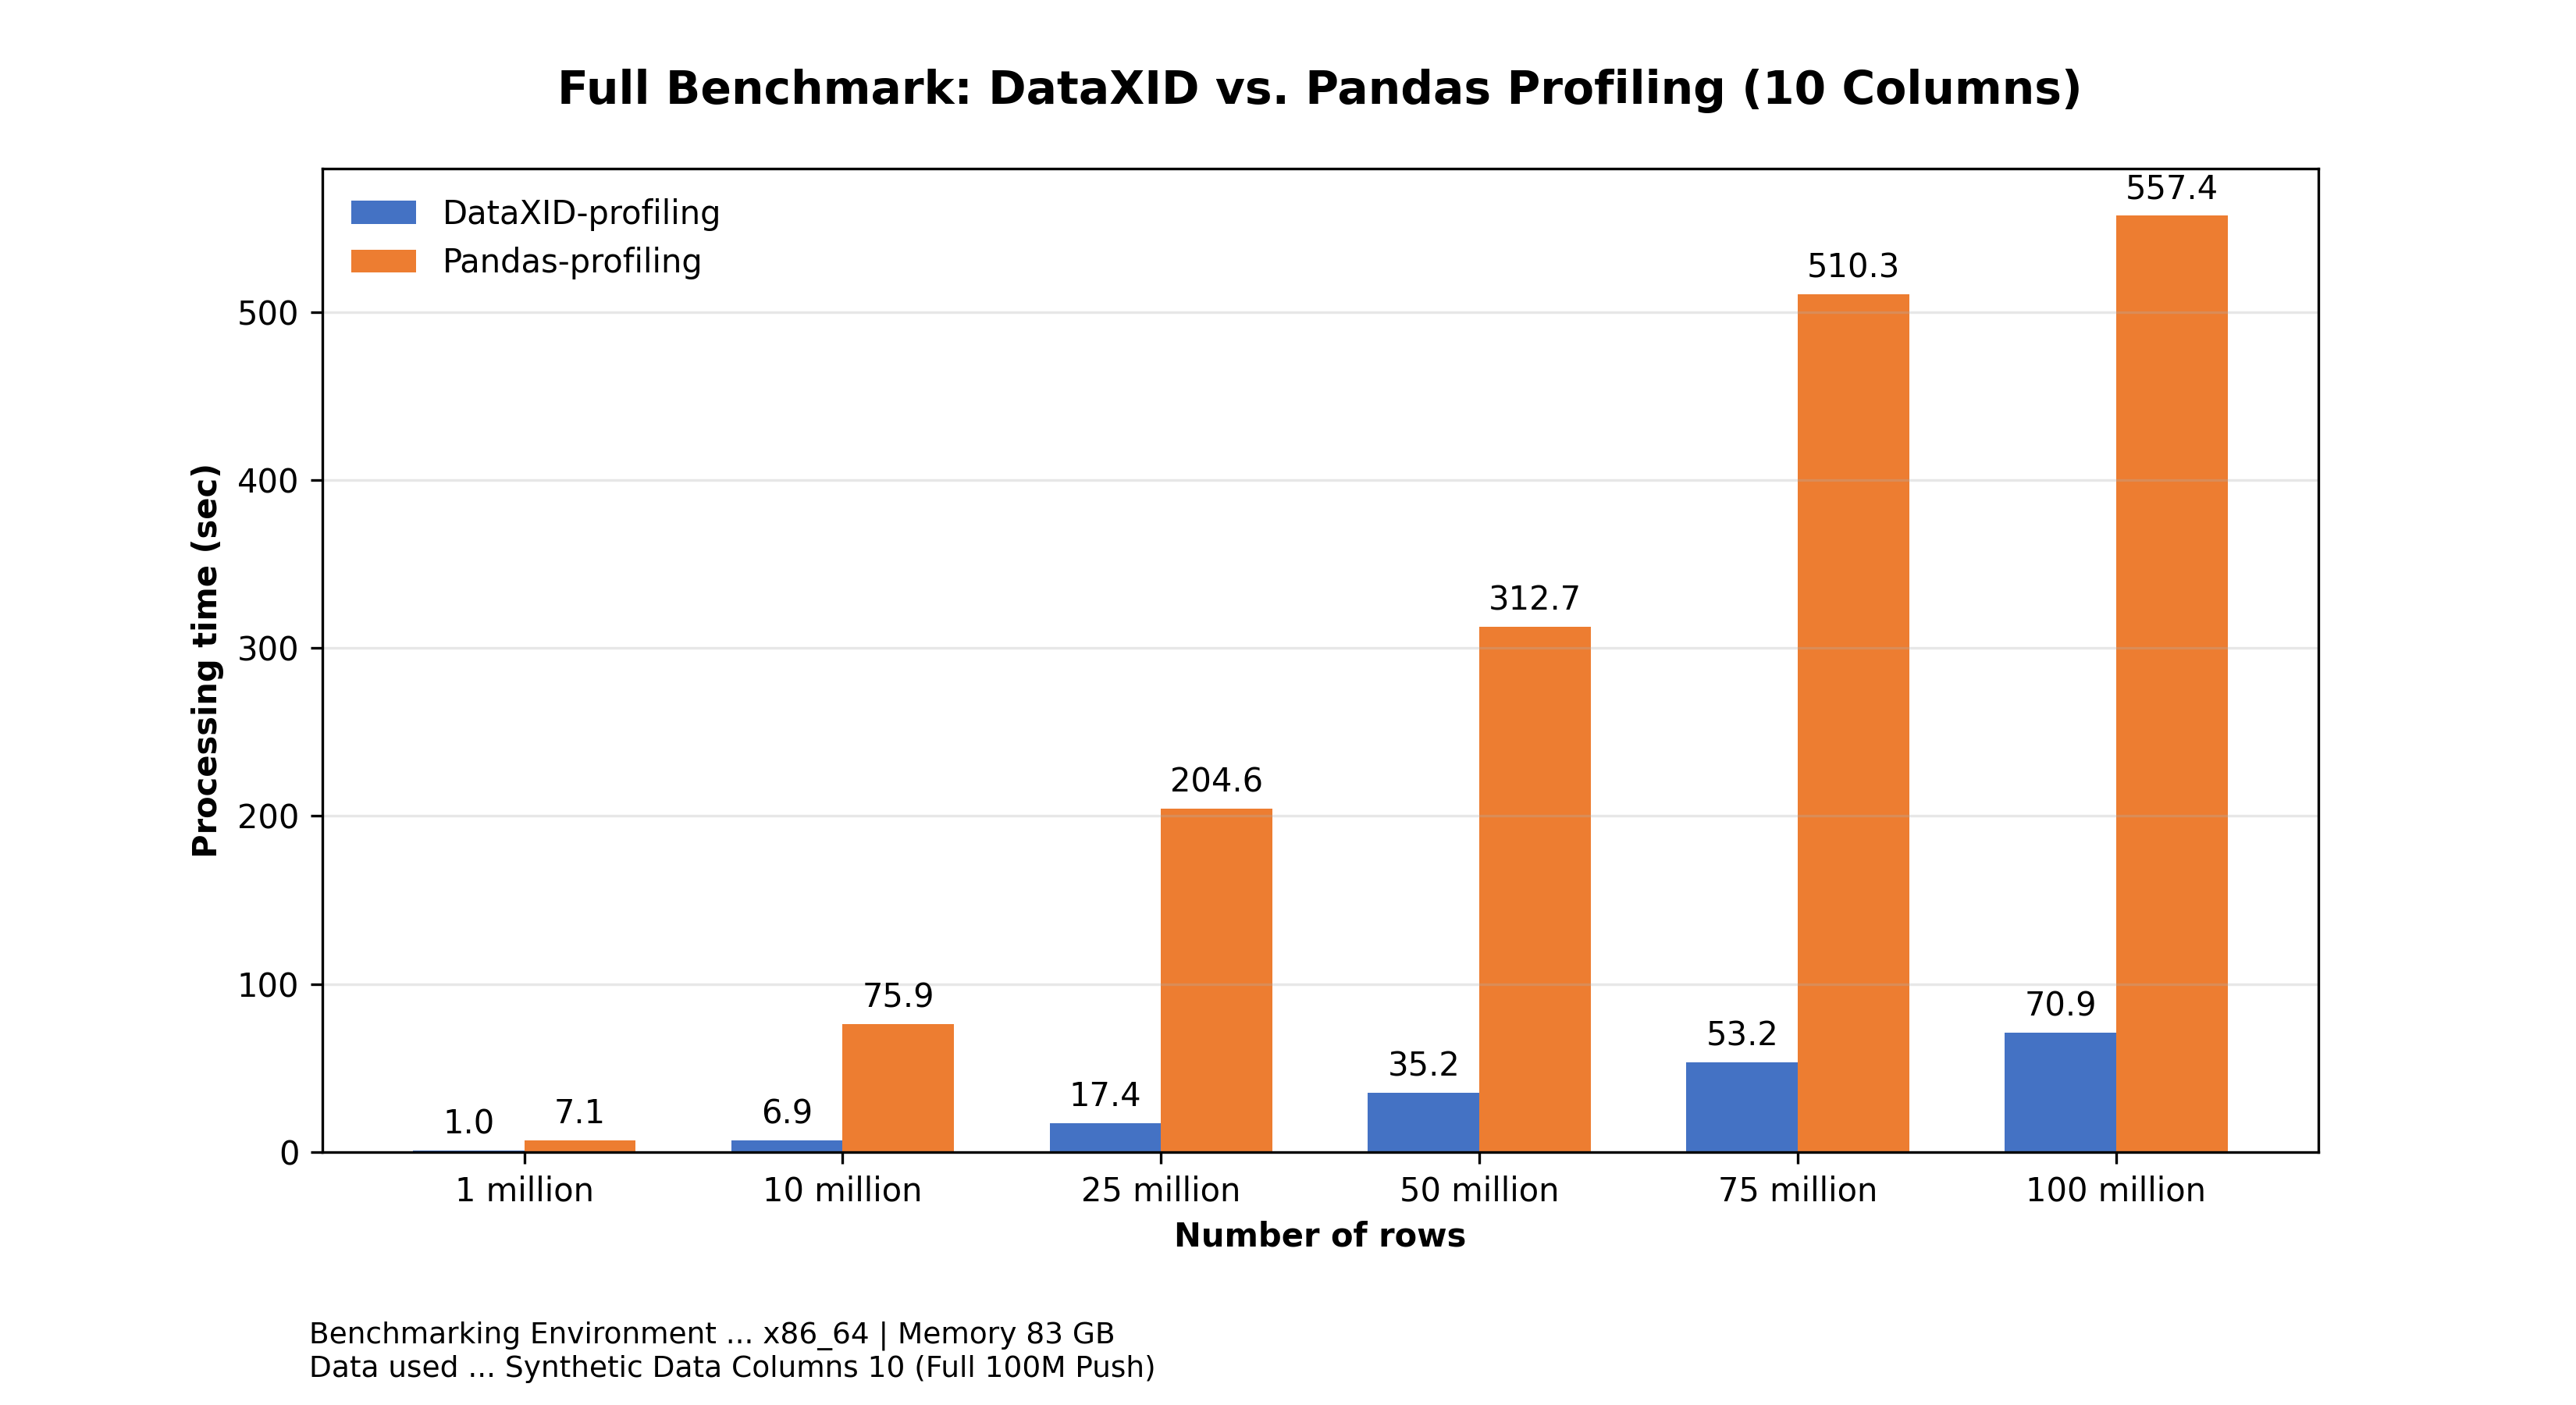